<a href="https://colab.research.google.com/github/Ewanjohndennis/ML_LAB/blob/main/assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Polynomial Regression using GridSearchCV

The following dataset represents the relationship between the number of hours spent practicing a skill and the performance score obtained in an assessment.

Build a **Polynomial Regression** model and use **GridSearchCV** to determine the optimal polynomial degree (1–5).

## Dataset

| Hours of Practice (X) | Performance Score (Y) |
|:---------------------:|:---------------------:|
| 1 | 3.2 |
| 2 | 5.1 |
| 3 | 8.8 |
| 4 | 15.6 |
| 5 | 25.4 |
| 6 | 38.2 |
| 7 | 54.1 |
| 8 | 73.5 |
| 9 | 96.8 |
| 10 | 123.2 |
| 11 | 154.6 |
| 12 | 190.8 |

## Tasks

- Create the dataset using **NumPy**.
- Split the data into **training and testing sets (80:20)**.
- Build a **Pipeline** consisting of:
  - PolynomialFeatures
  - LinearRegression
- Use **GridSearchCV** to search for the best polynomial degree from **1 to 5**.
- Use **5-fold cross-validation**.

## Display

- Best polynomial degree
- Best cross-validation score
- Predict the test set values

## Compute

- Mean Squared Error (MSE)
- R² Score

## Plot

- Original data
- Best fitted polynomial curve

Best Degree: 3
Best CV Score: 0.999977112661453
Mean Sqaured Error: 0.35897200298572524
R2 Score: 0.9999156637053938


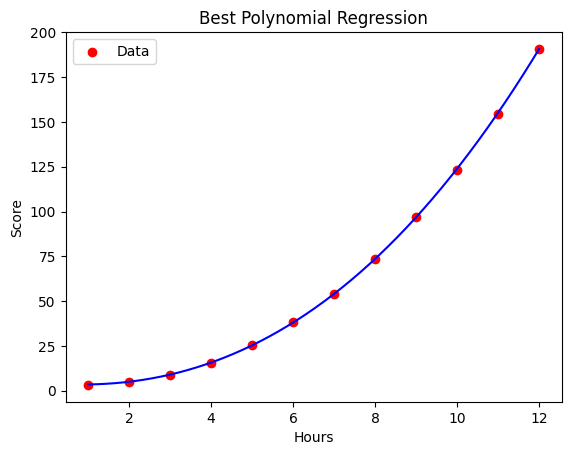

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X=np.array([1,2,3,4,5,6, 7, 8, 9, 10, 11, 12]).reshape(-1,1)
Y=np.array([3.2, 5.1, 8.8, 15.6, 25.4, 38.2, 54.1, 73.5, 96.8, 123.2, 154.6, 190.8])
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)
pipeline = Pipeline([
    ("poly", PolynomialFeatures()),
    ("linear", LinearRegression())
])
param_grid={
    "poly__degree":[1,2,3,4,5]
}
gridsearch=GridSearchCV(pipeline, param_grid,cv=3, scoring="r2")
gridsearch.fit(X_train, Y_train)
print("Best Degree:", gridsearch.best_params_["poly__degree"])
print("Best CV Score:", gridsearch.best_score_)
best_model=gridsearch.best_estimator_
Y_pred=best_model.predict(X_test)
print("Mean Sqaured Error:", mean_squared_error(Y_test, Y_pred))
print("R2 Score:", r2_score(Y_test, Y_pred))
X_plot=np.linspace(1,12,200).reshape(-1,1)
y_plot=gridsearch.predict(X_plot)

plt.scatter(X,Y,color="red",label="Data")
plt.plot(X_plot,y_plot,color="blue")
plt.xlabel("Hours")
plt.ylabel("Score")
plt.title("Best Polynomial Regression")
plt.legend()
plt.show()

Implement Polynomial Regression on Auto MPG dataset using GridSearch and Cross Validation to select the optimal polynomial degree for regression.

## Tasks

1. Load the Auto MPG dataset.

2. Preprocess the dataset.

3. Implement Polynomial Regression.

4. Use GridSearchCV to find the optimal polynomial degree.

5. Apply Cross Validation to evaluate the model.

6. Select the best polynomial model based on performance.

In [12]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
auto = fetch_openml(name="autoMpg", version=1, as_frame=True)

df = auto.frame
df = df.replace("?",np.nan)
df = df.dropna()
df["horsepower"] = df["horsepower"].astype(float)

X = df[["horsepower"]]
y = df["class"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

pipe = Pipeline([
    ("poly",PolynomialFeatures()),
    ("lr",LinearRegression())
])

param_grid={
    "poly__degree":[1,2,3,4,5]
}

grid=GridSearchCV(pipe,param_grid,cv=5)

grid.fit(X_train,y_train)

print("Best Degree:",grid.best_params_)
print("Best Score:",grid.best_score_)

pred=grid.predict(X_test)

print("MSE:",mean_squared_error(y_test,pred))
print("R2:",r2_score(y_test,pred))

Best Degree: {'poly__degree': 2}
Best Score: 0.6805904758396913
MSE: 18.416967796017616
R2: 0.6391701147013347


The following dataset represents the relationship between the study hours of students and their examination scores.

Fit Polynomial Regression models of different degrees (1 to 6).

Compare their training and testing errors to identify underfitting, overfitting, and the optimal model complexity.

## Dataset

| Hours Studied (X) | Exam Score (Y) |
|---|---|
| 1 | 5 |
| 2 | 8 |
| 3 | 15 |
| 4 | 24 |
| 5 | 36 |
| 6 | 50 |
| 7 | 67 |
| 8 | 85 |
| 9 | 108 |
| 10 | 130 |
| 11 | 158 |
| 12 | 190 |
| 13 | 225 |
| 14 | 265 |
| 15 | 310 |

The data approximately follows a quadratic relationship with a small amount of noise.

## Tasks

1. Create the dataset using NumPy.

2. Split the data into training and testing sets (70:30).

3. Train Polynomial Regression models with degrees 1-6

4. For each model:

- Calculate the training MSE.
- Calculate the testing MSE.

5. Display the results in a table.

6. Plot:

- Training Error vs Degree
- Testing Error vs Degree

7. Identify:

- Underfitting model
- Best model
- Overfitting model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV